In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import random

random.seed(42)

In [2]:
image_dir = "./dataset/imagesTr"
label_dir = "./dataset/labelsTr"

image_files = sorted(glob(os.path.join(image_dir, "*.nii.gz")))
label_files = [os.path.join(label_dir, os.path.basename(f)) for f in image_files]

# Randomly select 3 indices
sample_indices = random.sample(range(len(image_files)), 3)
sample_images = [image_files[i] for i in sample_indices]
sample_labels = [label_files[i] for i in sample_indices]

In [3]:
label_map = {
    1: "Edema",
    2: "Non-enhancing tumor",
    3: "Enhancing tumor"
}

In [4]:
def get_multilabel_vector(label_data):
    labels_present = sorted(set(np.unique(label_data)) - {0})  # exclude background
    multilabel = [int(k in labels_present) for k in label_map]
    label_names = [label_map[k] for k in labels_present]
    return multilabel, label_names

In [5]:
def plot_slices_with_labels(image_path, label_path):
    image_nifti = nib.load(image_path)
    label_nifti = nib.load(label_path)

    image = image_nifti.get_fdata()  # shape: H x W x D x C
    label = label_nifti.get_fdata().astype(int)  # shape: H x W x D

    mid_slice = image.shape[2] // 2
    multilabel, label_names = get_multilabel_vector(label)

    fig, axs = plt.subplots(1, 5, figsize=(22, 5))
    axs[0].imshow(image[:, :, mid_slice, 0], cmap="gray")
    axs[0].set_title("FLAIR")
    axs[1].imshow(image[:, :, mid_slice, 1], cmap="gray")
    axs[1].set_title("T1w")
    axs[2].imshow(image[:, :, mid_slice, 2], cmap="gray")
    axs[2].set_title("T1gd")
    axs[3].imshow(image[:, :, mid_slice, 3], cmap="gray")
    axs[3].set_title("T2w")
    axs[4].imshow(label[:, :, mid_slice], cmap="nipy_spectral", vmin=0, vmax=3)
    axs[4].set_title("Label Map")

    for ax in axs:
        ax.axis("off")

    # Add label info as a supertitle
    fig.suptitle(f"Assigned Labels: {', '.join(label_names) if label_names else 'None'}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


Visualizing: BRATS_328.nii.gz


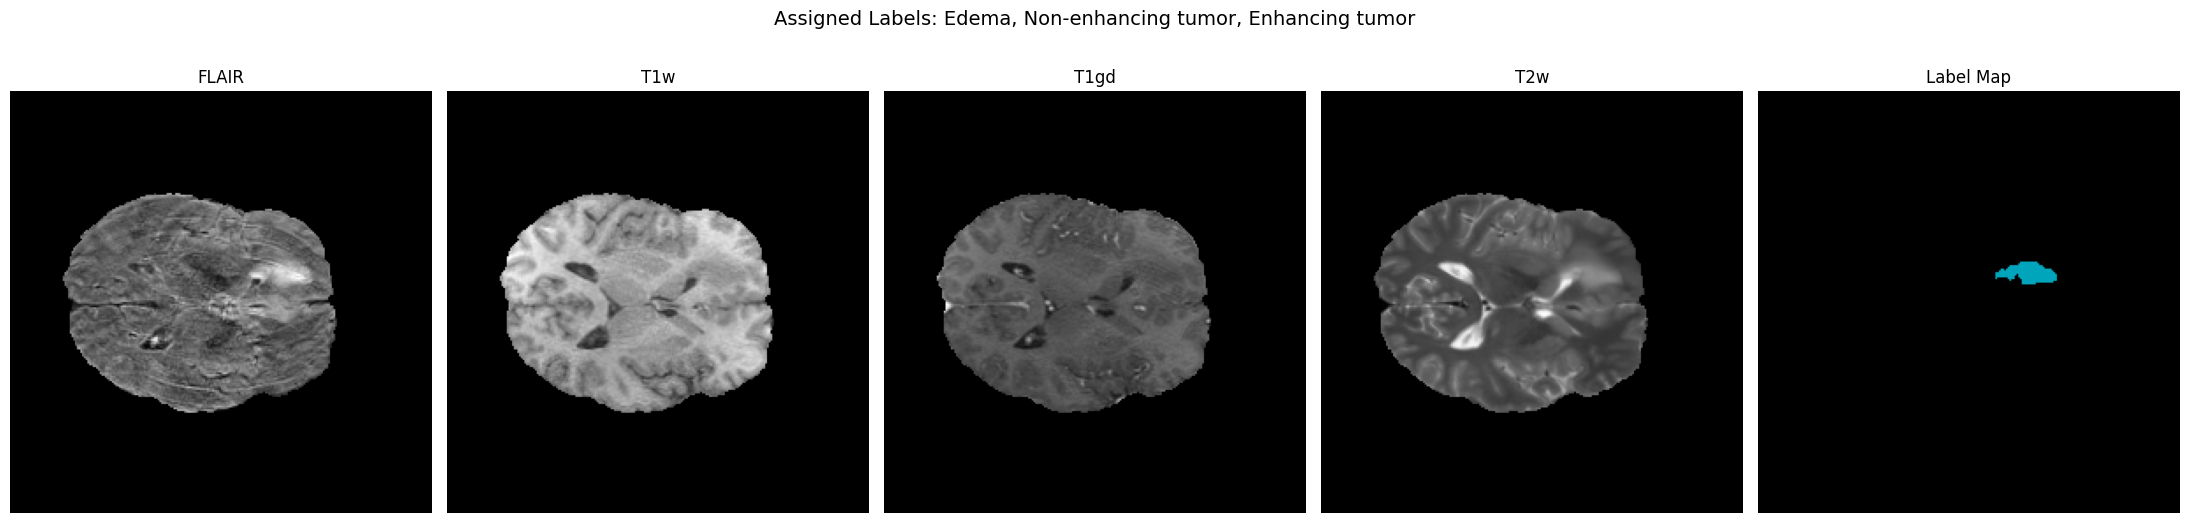


Visualizing: BRATS_058.nii.gz


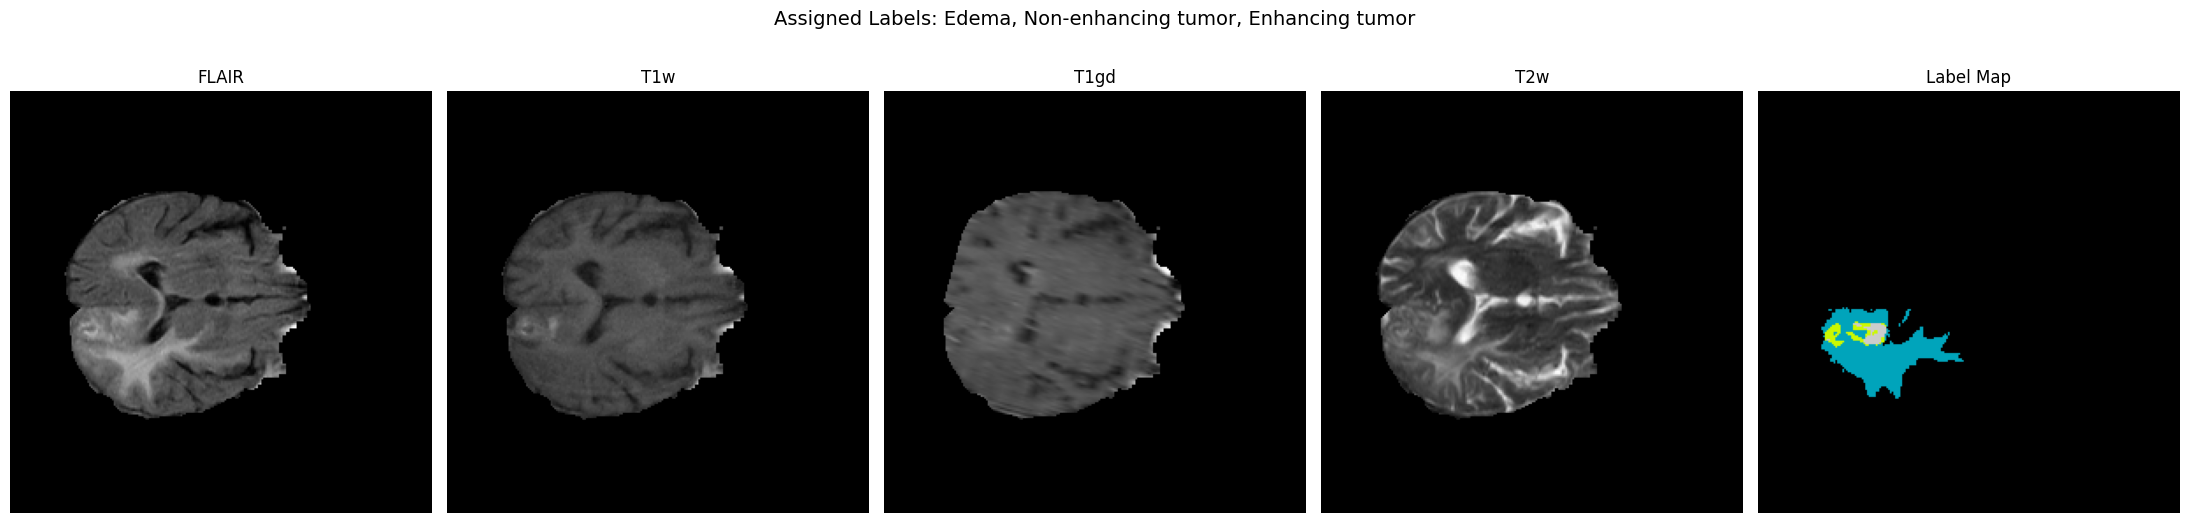


Visualizing: BRATS_013.nii.gz


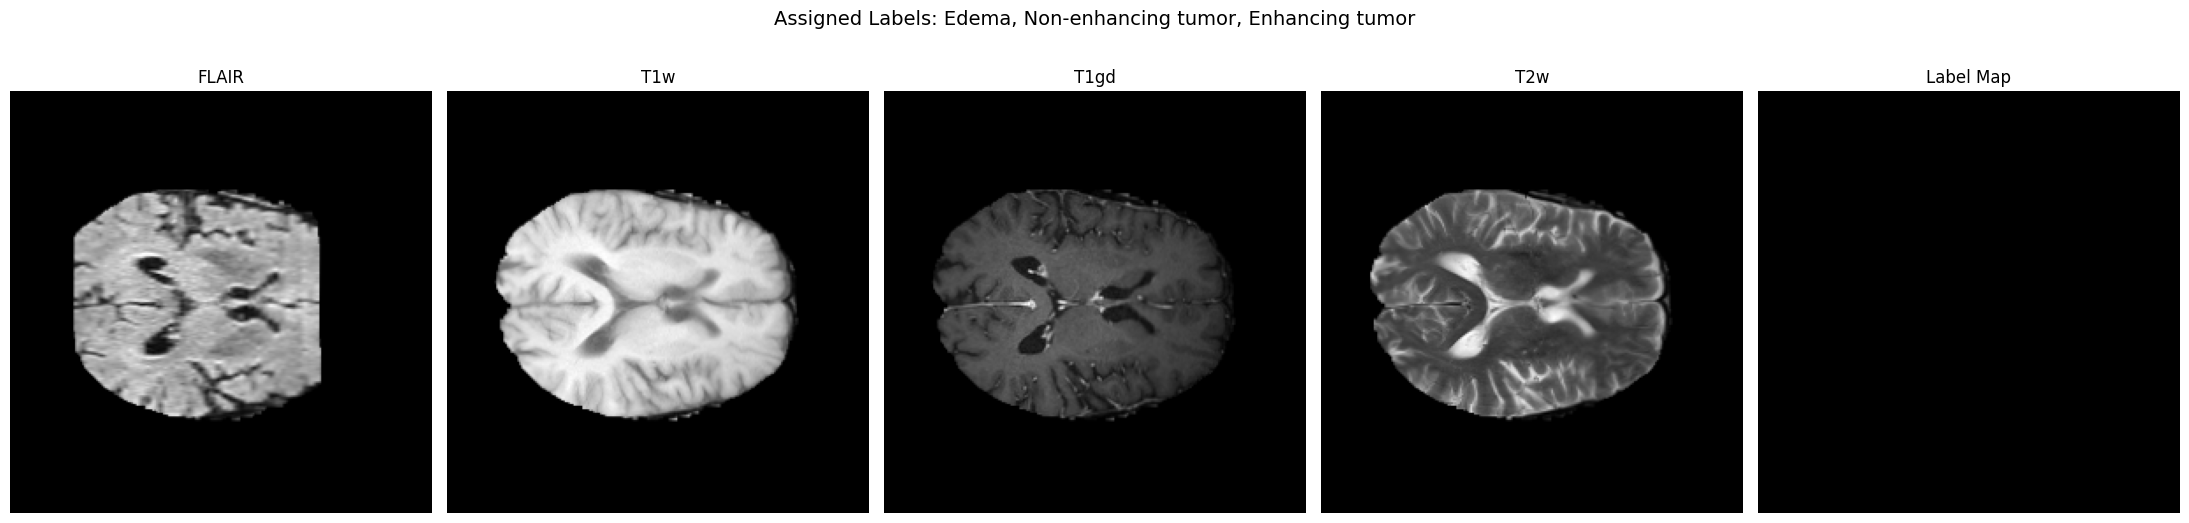

In [6]:
for img, lbl in zip(sample_images, sample_labels):
    print(f"\nVisualizing: {os.path.basename(img)}")
    plot_slices_with_labels(img, lbl)

In [7]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset
import random

In [8]:
class BRATSSliceDataset(Dataset):
    def __init__(self, image_label_pairs, modality_index=0, transform=None):
        """
        image_label_pairs: list of {'image': .nii path, 'label': .nii path}
        modality_index: selects the channel from 4D image volumes (0=FLAIR, 1=T1, etc.)
        transform: optional (image, mask) transform
        """
        self.modality_index = modality_index
        self.transform = transform
        self.slice_indices = []  # List of (image_path, label_path, slice_index)

        print("🔍 Indexing valid slices (this may take a few minutes)...")
        for pair in image_label_pairs:
            image_path = pair['image']
            label_path = pair['label']

            try:
                image_data = nib.load(image_path).get_fdata()
                label_data = nib.load(label_path).get_fdata()

                # Get the selected modality: shape (H, W, D)
                if image_data.ndim == 4:
                    image_modality = image_data[..., modality_index]
                else:
                    raise ValueError(f"Expected 4D image, got shape: {image_data.shape}")

                for i in range(image_modality.shape[2]):
                    mask_slice = label_data[:, :, i]
                    if np.any(mask_slice > 0):  # include only tumor-containing slices
                        self.slice_indices.append((image_path, label_path, i))

            except Exception as e:
                print(f"Skipped {image_path}: {e}")

        print(f"Indexed {len(self.slice_indices)} tumor slices.")

    def __len__(self):
        return len(self.slice_indices)

    def __getitem__(self, idx):
        image_path, label_path, slice_idx = self.slice_indices[idx]

        image = nib.load(image_path).get_fdata()[..., self.modality_index][:, :, slice_idx]
        mask = nib.load(label_path).get_fdata()[:, :, slice_idx]

        # Normalize: z-score
        image = (image - np.mean(image)) / (np.std(image) + 1e-5)

        # Add channel dimension
        image = np.expand_dims(image, axis=0)

        if self.transform:
            image, mask = self.transform(image, mask)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

In [9]:
import matplotlib.pyplot as plt
import random

def visualize_sample(dataset, num_samples=5):
    """Randomly visualize a few image slices and their masks"""
    indices = random.sample(range(len(dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        image = image[0]  # remove channel dim

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Image Slice {idx}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='nipy_spectral', interpolation='none')
        plt.title("Segmentation Mask")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


In [10]:
import json
import os
from pathlib import Path
from sklearn.model_selection import train_test_split

# Paths
json_path = Path('./dataset_unzipped/dataset_unzipped.json').resolve()  # Path to your updated JSON
unzipped_base_dir = Path('./dataset_unzipped').resolve()  # Path where unzipped .nii files are stored

# Function to load and resolve full paths
def load_train_pairs(json_path, base_dir):
    with open(json_path) as f:
        data_info = json.load(f)

    full_pairs = []
    for p in data_info['training']:
        full_image = os.path.join(base_dir, p['image'])
        full_label = os.path.join(base_dir, p['label'])
        full_pairs.append({
            'image': os.path.normpath(full_image),
            'label': os.path.normpath(full_label)
        })
    
    return full_pairs

# Load full dataset and split into train/val
all_pairs = load_train_pairs(json_path, base_dir=unzipped_base_dir)
train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

# Dataset class from earlier
train_dataset = BRATSSliceDataset(train_pairs, modality_index=0)
val_dataset = BRATSSliceDataset(val_pairs, modality_index=0)


🔍 Indexing valid slices (this may take a few minutes)...
Indexed 27042 tumor slices.
🔍 Indexing valid slices (this may take a few minutes)...
Indexed 6713 tumor slices.


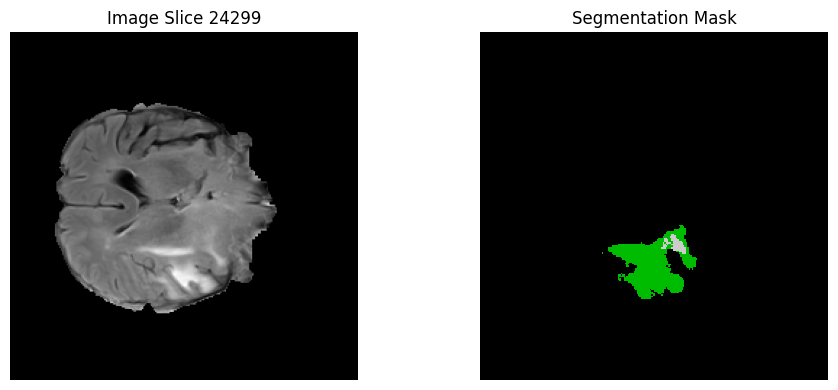

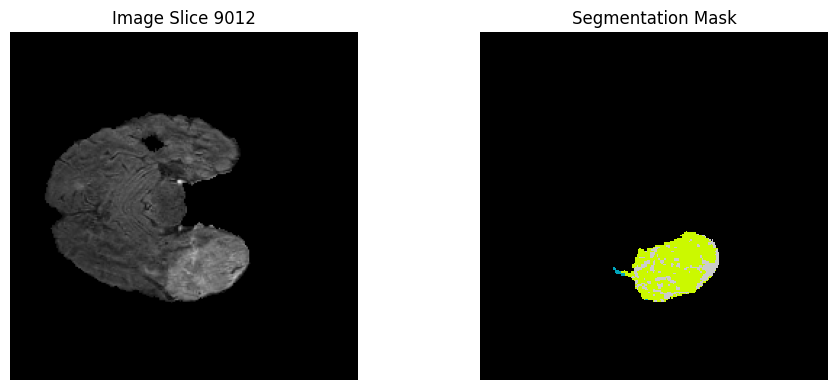

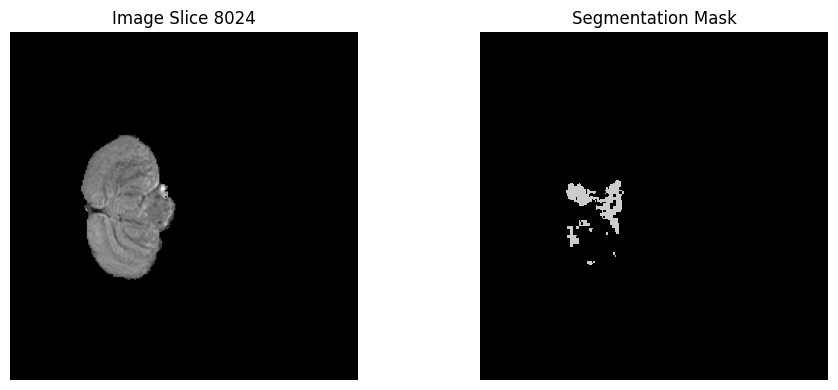

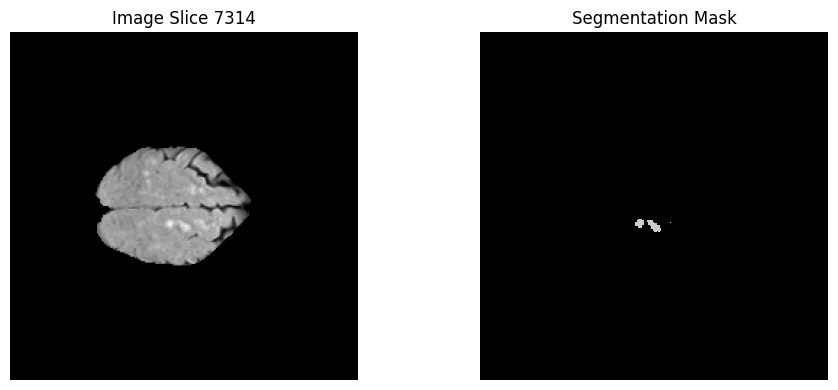

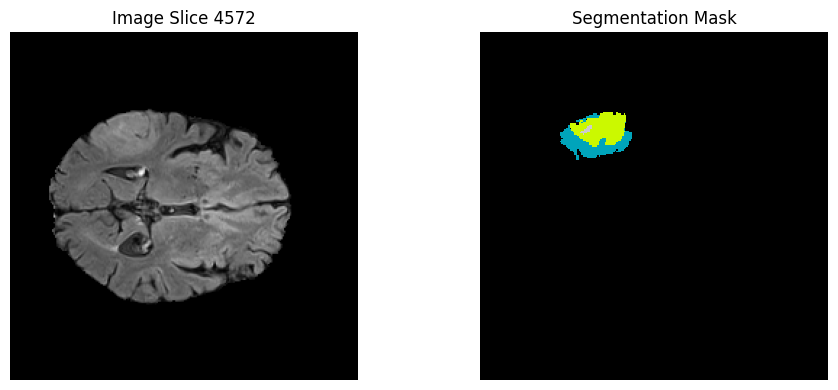

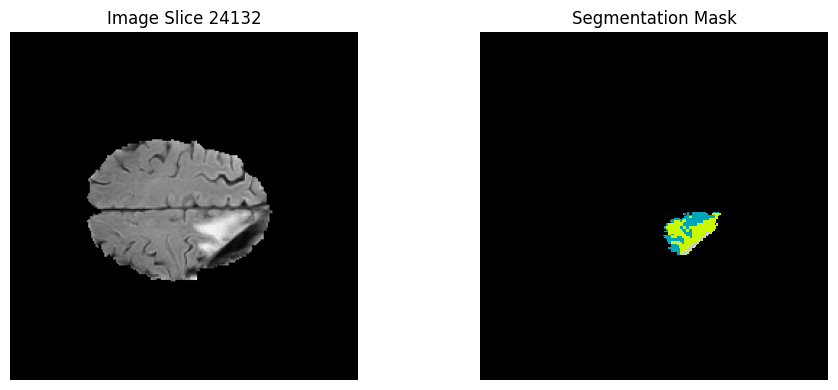

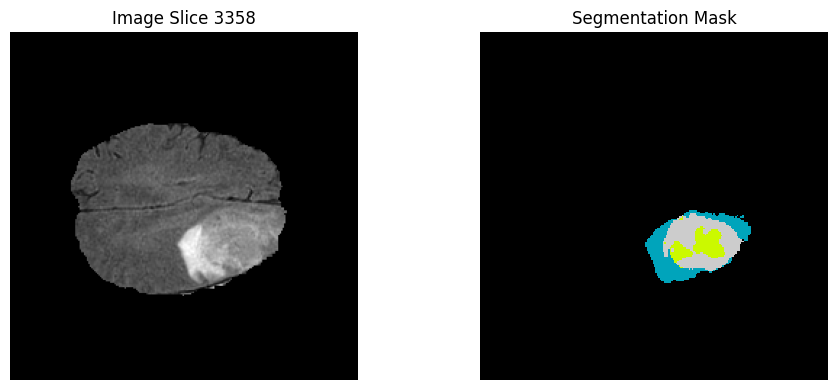

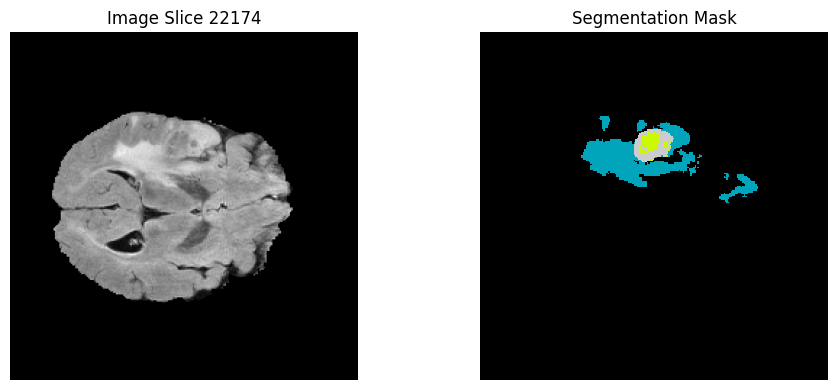

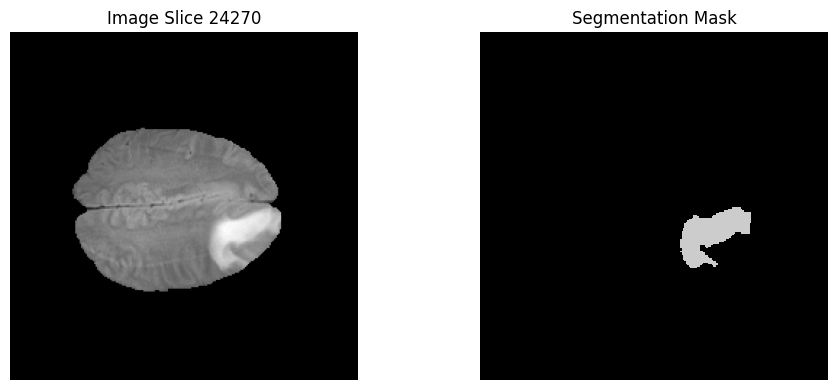

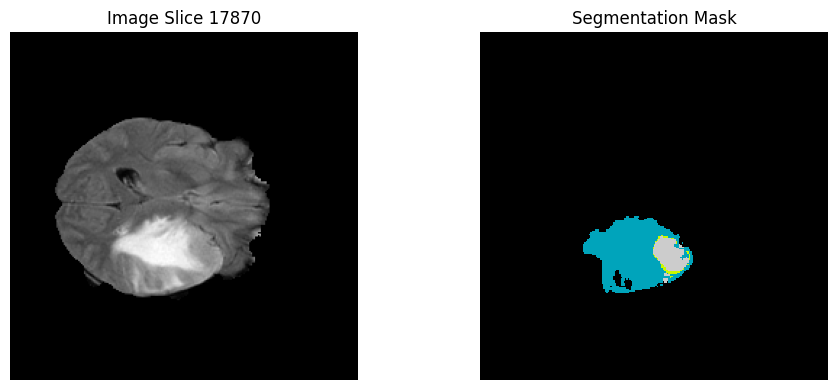

In [11]:
# Visualize
visualize_sample(train_dataset, num_samples=10)

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, features=[64, 128, 256, 512]):
        super(UNet2D, self).__init__()

        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()

        # Encoder (Down)
        for feature in features:
            self.encoder.append(self._conv_block(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self._conv_block(features[-1], features[-1]*2)

        # Decoder (Up)
        for feature in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.decoder.append(self._conv_block(feature*2, feature))

        # Final output layer
        self.output_layer = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def _conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip_connections = []
        for down in self.encoder:
            x = down(x)
            skip_connections.append(x)
            x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            x = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx + 1](x)

        return self.output_layer(x)


In [13]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def dice_score(preds, targets, num_classes=4):
    """Compute Dice score for each class and return average"""
    preds = torch.argmax(preds, dim=1)
    dice = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice_cls = (2. * intersection + 1e-5) / (union + 1e-5)
        dice.append(dice_cls.item())
    
    return sum(dice) / len(dice)


In [14]:
def train_model(model, train_dataset, val_dataset=None, num_epochs=10, batch_size=8, lr=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False) if val_dataset else None

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_dice = 0

        loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_score(preds, masks)

            loop.set_postfix(loss=loss.item())

        avg_loss = train_loss / len(train_loader)
        avg_dice = train_dice / len(train_loader)
        print(f'Epoch {epoch+1}: Loss={avg_loss:.4f}, Dice={avg_dice:.4f}')

        # Optional validation loop
        if val_loader:
            model.eval()
            val_dice = 0
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    preds = model(images)
                    val_dice += dice_score(preds, masks)
            print(f'Validation Dice: {val_dice / len(val_loader):.4f}')


In [15]:
# from sklearn.model_selection import train_test_split

# with open('./dataset_unzipped/dataset_unzipped.json') as f:
#     dataset_info = json.load(f)

# pairs = dataset_info['training']
# train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

# # Efficient 2D dataset
# train_dataset = BRATSSliceDataset(train_pairs, modality_index=0)
# val_dataset = BRATSSliceDataset(val_pairs, modality_index=0)

In [ ]:
model = UNet2D(in_channels=1, out_channels=4)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
train_model(model, train_dataset, val_dataset, num_epochs=3)

Epoch 1/3:   0%|                                                                                                         | 0/3381 [00:00<?, ?it/s]C:\Users\adria\anaconda3\envs\bratc\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 1/3:   4%|███▏                                                                            | 137/3381 [13:52<5:24:09,  6.00s/it, loss=0.0989]

In [ ]:
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"✅ Model saved to: {path}")

In [ ]:
model_path = 'models/unet2d_final.pth'
os.makedirs(model_path, exist_ok=True)
save_model(model, model_path)


In [ ]:
def evaluate_model(model, val_dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
    total_dice = 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            total_dice += dice_score(preds, masks)

    avg_dice = total_dice / len(val_loader)
    print(f'🧪 Validation Dice Score: {avg_dice:.4f}')


In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, val_dataset, num_samples=5, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    indices = random.sample(range(len(val_dataset)), num_samples)

    with torch.no_grad():
        for idx in indices:
            image, true_mask = val_dataset[idx]
            image = image.unsqueeze(0).to(device)
            pred_mask = model(image)
            pred_mask = torch.argmax(pred_mask, dim=1).squeeze(0).cpu().numpy()
            true_mask = true_mask.numpy()
            image = image.squeeze().cpu().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(image, cmap='gray')
            plt.title('Image')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask, cmap='nipy_spectral')
            plt.title('Ground Truth')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask, cmap='nipy_spectral')
            plt.title('Prediction')
            plt.axis('off')
            plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_metrics(model, dataset, num_classes=4, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    
    dice_scores = np.zeros(num_classes)
    total_pixels = 0
    correct_pixels = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Pixel accuracy
            correct_pixels += (preds == masks).sum().item()
            total_pixels += torch.numel(masks)

            # Dice score
            for cls in range(num_classes):
                pred_cls = (preds == cls).float()
                true_cls = (masks == cls).float()
                intersection = (pred_cls * true_cls).sum()
                union = pred_cls.sum() + true_cls.sum()
                dice = (2 * intersection + 1e-5) / (union + 1e-5)
                dice_scores[cls] += dice.item()

            # Confusion matrix
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(masks.cpu().numpy().flatten())

    avg_dice = dice_scores / len(loader)
    accuracy = correct_pixels / total_pixels
    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))

    print(f"\n📊 Evaluation Results:")
    for i, d in enumerate(avg_dice):
        print(f"  Dice Class {i}: {d:.4f}")
    print(f"  Pixel Accuracy: {accuracy:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    return avg_dicte, accuracy, cm


In [ ]:
evaluate_model(model, val_dataset)
evaluate_metrics(model, val_dataset)
visualize_predictions(model, val_dataset, num_samples=10)
